In [1]:
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot as plt

os.chdir("/home/dataobrii04/PyProjects/nuam_scraper")
df = pd.read_parquet("./nuam_artists.parquet")

# Preprocessing

In [2]:
# Replace all empty strings with NaN for easier processing
df.replace("", np.nan, inplace=True)

mapping = {"Артист": "artist_name", 
                   "Жанр": "genre",
                   "Дата додавання": "date_added",
                    "Instagram": "instagram",
                    "Empty": "is_empty_flag",
                    "RuLang": "ru_lang_flag",
                    "YearRel": "last_year_release_flag",
                    "MultiRel": "more_than_one_release_flag",
                    "ОписCheck": "invalid_description_flag",
                    "Опис": "is_description_present_flag",
                    "City": "city",
                   }

def process_flag(df, col, default = True):
    df[col] = df[col].replace({"+": 1, "-": 0, "": np.nan}).fillna(default).astype(bool)
    return df[col]

df.rename(columns=mapping | {"Debut": "Debut26"}, inplace=True)

process_flag(df, "is_empty_flag", default = False)
process_flag(df, "ru_lang_flag", default = False)
process_flag(df, "last_year_release_flag", default = False)
process_flag(df, "more_than_one_release_flag", default = False)
process_flag(df, "invalid_description_flag", default = True)
process_flag(df, "is_description_present_flag", default = False)


# Assign id to artists for mapping
df["artist_id"] = df.index

# Coalesce columns starting with "URL" into a single "url" column
url_cols = [col for col in df.columns if col.startswith("URL")]
df["url"] = df[url_cols].bfill(axis=1).iloc[:, 0]

# Add to spotify columns all urls that contain "spotify" in the value
df["spotify"] = df[url_cols].apply(lambda row: next((val for val in row if isinstance(val, str) and "spotify" in val), np.nan), axis=1)

df["spotify_id"] = df["spotify"].str.extract(r'/artist/(.*)', expand=False)

# Mapping id to artist name for later use
artist_id_to_name = df.set_index("artist_id")["artist_name"].to_dict()
artist_name_to_id = df.set_index("artist_name")["artist_id"].to_dict()

In [3]:
# relations_list = []
# for value in df["relations"]:
#     relations_list.extend(value.split(","))

In [4]:
cyrylic_listeners_wide_cols = [c for c in df.columns if c.startswith("Слухачів")]

listeners_long_fmt = []
for col in cyrylic_listeners_wide_cols:
    mask = df[col].notna()
    #Parse date format 06.24
    month_datetime = pd.to_datetime(col.split(" ")[-1], format="%m.%y")
    listeners_per_month = pd.DataFrame({"artist_id": df["artist_id"][mask], "artist_name": df["artist_name"][mask], "listeners": pd.to_numeric(df[col][mask], errors="coerce"), "month": month_datetime})
    listeners_long_fmt.append(listeners_per_month)

listeners_df = pd.concat(listeners_long_fmt, ignore_index=True).sort_values(["artist_id", "month"])

In [5]:
debut_wide_cols = [c for c in df.columns if c.startswith("Debut")]
debut_long_fmt = []
for col in debut_wide_cols:
    mask = df[col].notna()
    year = int(col[-2])+2000

    debut_per_year = pd.DataFrame({"artist_id": df["artist_id"][mask], "artist_name": df["artist_name"][mask], "is_debuted": process_flag(df[mask], col, default = False), "year": year})
    debut_long_fmt.append(debut_per_year)

debut_df = pd.concat(debut_long_fmt, ignore_index=True).sort_values(["artist_id", "year"])

In [6]:
label_wide_cols = [c for c in df.columns if  c.startswith("Label")]
labels_long_fmt = []
for col in label_wide_cols:
    mask = df[col].notna()
    label_per_artist = pd.DataFrame({"artist_id": df["artist_id"][mask], "artist_name": df["artist_name"][mask], "label": df[col][mask]})
    labels_long_fmt.append(label_per_artist)
labels_df = pd.concat(labels_long_fmt, ignore_index=True).sort_values(["artist_id"])

In [7]:
genres_long_fmt = []
for row in df.itertuples():
    if pd.notna(row.genre):
        genres = [g.strip() for g in row.genre.split(",")]
        for genre in genres:
            genres_long_fmt.append({"artist_id": row.artist_id, "artist_name": row.artist_name, "genre": genre})
genres_df = pd.DataFrame(genres_long_fmt).sort_values(["artist_id", "genre"])

In [8]:
df["has_label_flag"] = df[label_wide_cols].notna().any(axis=1)
df['has_debut_in_last_three_years_flag'] = df[debut_wide_cols].iloc[:, -3:].any(axis=1)

artists_df = df[list(mapping.values())+["url", "spotify", "artist_id"]]

### Basic metrics

In [9]:
artists_df.describe().T

,count,mean,std,min,25%,50%,75%,max
artist_id,17349.0,8674.0,5008.369246,0.0,4337.0,8674.0,13011.0,17348.0


In [10]:
genres_df["genre"].describe().T

count     25496
unique      105
top         pop
freq       5715
Name: genre, dtype: object

In [11]:
labels_df.groupby("label").size().sort_values(ascending=False).head(10)

label
PLAN                 379
Muzika UA Publish    294
BEST MUSIC           268
TAVR Records         255
VG STAR              183
NPRC MUSIC           179
Black Beats          171
Moon Vinyl s.r.o.    158
Mayak Music          128
Gm Digital           124
dtype: int64

In [12]:
labels_df.groupby("artist_name").size().sort_values(ascending=False).head(10)

artist_name
Incorrect Waves        6
Kolaba                 5
radiant futur          5
KAZKA                  5
VECHIR                 5
Alter (UA)             5
Rhytmograph            5
ANIT                   5
Stanislav Tolkachev    5
TINA PETRIV            5
dtype: int64

In [13]:
listeners_df.groupby("artist_name")["month"].min().value_counts()

month
2024-04-01    11054
2025-05-01      525
2025-08-01      496
2024-10-01      464
2025-01-01      406
2024-11-01      381
2025-03-01      335
2025-06-01      334
2025-10-01      326
2025-02-01      322
2025-12-01      301
2024-08-01      290
2025-07-01      281
2025-04-01      280
2025-11-01      261
2026-01-01      251
2025-09-01      248
2024-12-01      243
2026-03-01      191
2026-02-01      140
2026-04-01       52
Name: count, dtype: int64

In [14]:
artists_df["debut_month"] = artists_df["artist_id"].map(listeners_df.groupby("artist_name")["month"].min())

# Charts

## **The Unlikely Odds of Making it Big in Ukraine**

The Ukrainian music market is relatively young and has undergone dramatic transformations over the past century. Under the Soviet Union, Ukrainian culture — including music — existed within a framework that often favored Russian‑language cultural production and tightly controlled local cultural expression. After independence in 1991, Ukrainian pop and contemporary music gradually revived, but Russian‑language songs remained common in the market because they reached larger audiences across the post‑Soviet space. ([Wikipedia][1])

In the 2000s and early 2010s, Ukrainian artists increasingly built local followings through domestic festivals and television, and social media expanded opportunities for promotion and audience building. However, many musicians still recorded in Russian to gain wider reach within the larger Russian‑speaking market. ([Wikipedia][1])

**The turning point came after 2014** and **especially after Russia’s full‑scale invasion in February 2022**. Following these events, both cultural identity and language began reshaping the industry — Ukrainian‑language music surged in popularity and became mainstream. By 2025, Ukrainian‑language content accounted for a majority of music consumption in Ukraine, up significantly from before the invasion. ([Межа. Новини України.][2])

At the same time, new legislation in 2022 restricted public performance and broadcast of many Russian‑language songs and increased Ukrainian content quotas on radio and television, further accelerating the shift toward Ukrainian music as the dominant cultural force. ([Wikipedia][3])

Despite this cultural revitalization, **economic realities for most musicians remain tough**. Earlier research showed that for over four‑fifths of Ukrainian artists, income from music alone often does not cover basic living costs, highlighting the challenges of professional success within the local market. ([Platfor.ma][4])

Today, the Ukrainian music scene is experiencing a renaissance shaped by war, national identity, digital platforms, and evolving audience preferences. This period — from 2022 through 2026 — represents a generation‑defining decade for artists striving to break through in a market that’s simultaneously becoming more local and more global.

### **Total Listeners Over Time (2024–2026)**

[d3 chart is here](data/charts/uk_listeners_growth/index.html)

The chart above illustrates the growth in total listeners in the Ukrainian music scene from 2024 to early 2026, based on data from **NUAM (New UA Music)** — a leading Ukrainian online music resource. The dataset, with a snapshot from April 2026, shows a steady rise in listener engagement, reflecting the ongoing transformation of the local music market.

NUAM is one of the largest publicly accessible databases of Ukrainian musicians, maintaining detailed profiles of tens of thousands of artists and their releases. It allows users to explore and filter music by genre, popularity, release date, and more. The platform also provides playlists, yearly charts, and genre collections. Through its web app, **NUAM Base**, it offers valuable analytics for both artists and fans, enabling a deeper understanding of the local music scene.

In recent months, the number of listeners has been consistently growing. Several factors may explain this trend:

1. **Increasing Number of Artists**
   As more artists join the scene and release music, the total number of listeners naturally increases. Since NUAM began tracking the platform, the number of active Ukrainian musicians has surged, with over 16,500 artists and more than 9,200 releasing music in 2025 alone.

2. **Aggregation Across Artists**
   The listener count aggregates data across all artists, which means that if the same listener discovers multiple artists, this could inflate the total listener count. This overlap in the listener base could cause a higher number of total listeners, even if the same individuals are responsible for the increase.

3. **Genuine Growth in Audience**
   If the listener bases of artists significantly do not overlap, the chart might reflect real growth in the number of unique listeners. This would indicate a deeper, more widespread interest in local Ukrainian music, which has been steadily rising since the onset of the war in 2022 and the cultural resurgence that followed.

Regardless of these technical nuances, all signs point to a **growing interest in local music**. This trend isn’t unique to Ukraine; it's part of a global shift where regional music markets are flourishing as audiences become more invested in local cultures. The rise of digital streaming platforms such as Spotify and Apple Music has played a significant role in amplifying this growth. As more people tune in to discover local talent, the future of the Ukrainian music scene looks promising.


In [15]:
listeners_df["listeners"].dtype

dtype('int64')

In [16]:
listeners_df.month.min(), listeners_df.month.max()

(Timestamp('2024-04-01 00:00:00'), Timestamp('2026-04-01 00:00:00'))

<Axes: title={'center': 'Total Listeners Over Time'}, xlabel='month'>

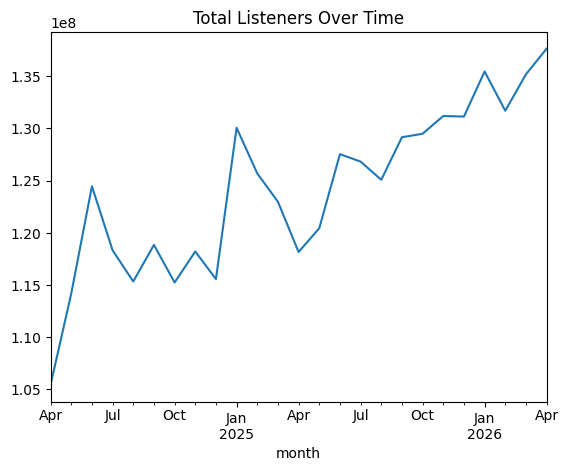

In [17]:
listeners_df.groupby("month")["listeners"].sum().plot(kind="line", title="Total Listeners Over Time")

In [18]:
listeners_df.groupby("month")["listeners"].min()

month
2024-04-01    0
2024-05-01    0
2024-06-01    0
2024-07-01    0
2024-08-01    0
2024-09-01    0
2024-10-01    0
2024-11-01    0
2024-12-01    0
2025-01-01    0
2025-02-01    0
2025-03-01    0
2025-04-01    0
2025-05-01    0
2025-06-01    0
2025-07-01    0
2025-08-01    0
2025-09-01    0
2025-10-01    0
2025-11-01    0
2025-12-01    0
2026-01-01    0
2026-02-01    0
2026-03-01    0
2026-04-01    0
Name: listeners, dtype: int64

<Axes: title={'center': 'Total Listeners Over Time'}, xlabel='month'>

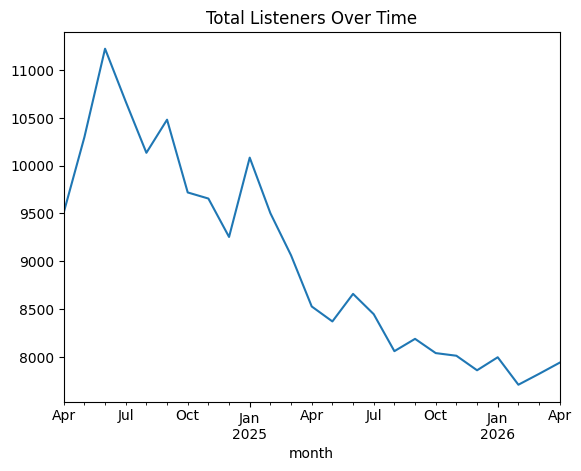

In [19]:
listeners_df.groupby("month")["listeners"].mean().plot(kind="line", title="Total Listeners Over Time")

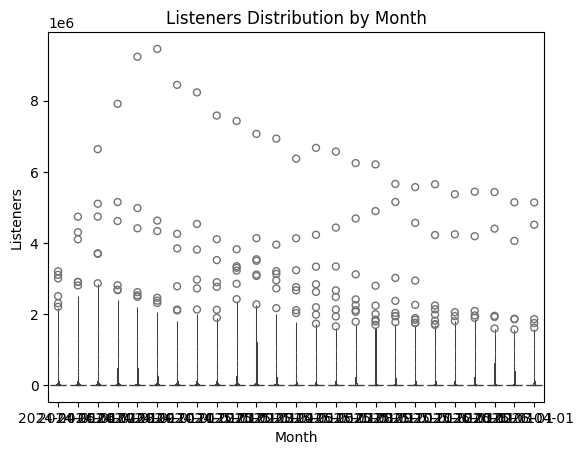

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# violin plot of listeners grouped by month
sns.boxenplot(
    x="month",         # categories on x
    y="listeners",     # distribution on y
    data=listeners_df,
    # inner="quartile"   # show quartiles inside violin
)

plt.title("Listeners Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Listeners")
plt.show()

### **How Many Listeners Do Ukrainian Artists Have?**

We analyzed the listener distribution of Ukrainian artists over the past month to better understand the market's potential. The results revealed that only **~5%% of artists** have surpassed the **320,000 listener** mark. The upper boundary for listeners is **1.8 million**, but we’ll leave the identity of that top performer a mystery for now ``;)``

For this analysis, we set a threshold of **400,000 listeners** to identify the most promising and successful artists in the Ukrainian market at present. Artists who reach this milestone are positioned as some of the most influential players in the industry, reflecting both established fan bases and the growing appeal of Ukrainian music.


/tmp/ipykernel_1318234/1444008305.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f"{int(np.expm1(tick)):,}" for tick in ticks])


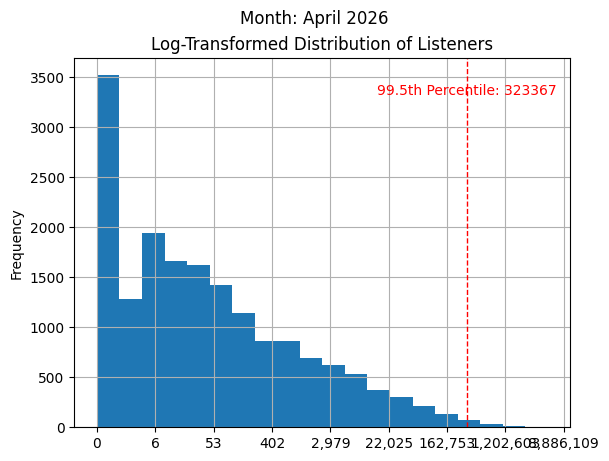

In [68]:
last_month_listeners = listeners_df[listeners_df["month"] == listeners_df["month"].max()]["listeners"]
last_month_listeners_log = np.log1p(last_month_listeners)  # log-transform the data for better visualization
last_month_listeners_log.hist(bins=20)
plt.title("Log-Transformed Distribution of Listeners")
plt.suptitle(f"Month: {listeners_df['month'].max().strftime('%B %Y')}")
plt.ylabel("Frequency")

# Set vertical line for .95 quantile
quantile_95_listeners = int(last_month_listeners.quantile(0.995))
quantile_95 = np.log1p(quantile_95_listeners)
plt.axvline(quantile_95, color='red', linestyle='dashed', linewidth=1)
plt.text(quantile_95, plt.ylim()[1]*0.9, f'99.5th Percentile: {quantile_95_listeners}', color='red', ha='center')

#convert ticks to original scale
ticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([f"{int(np.expm1(tick)):,}" for tick in ticks])  
plt.show()

/tmp/ipykernel_1318234/689431092.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f"{int(np.expm1(tick)):,}" for tick in ticks])


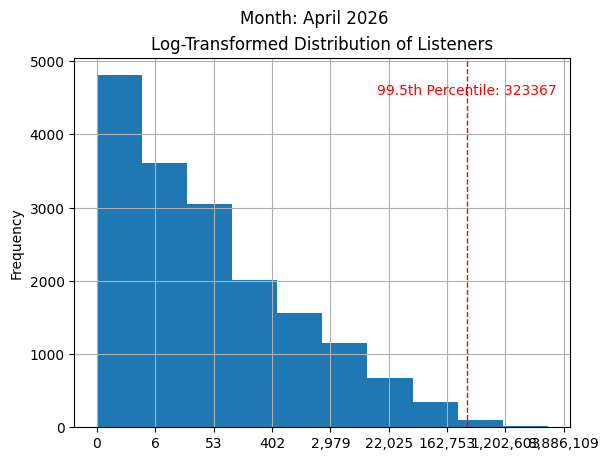

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming listeners_df is already defined
last_month_listeners = listeners_df[listeners_df["month"] == listeners_df["month"].max()]["listeners"]
last_month_listeners_log = np.log1p(last_month_listeners)  # log-transform the data for better visualization

# Plot histogram with qbin = 10
qbin = 10
last_month_listeners_log.hist(bins=qbin)
plt.title("Log-Transformed Distribution of Listeners")
plt.suptitle(f"Month: {listeners_df['month'].max().strftime('%B %Y')}")
plt.ylabel("Frequency")

# Set vertical line for .995 quantile
quantile_95_listeners = int(last_month_listeners.quantile(0.995))
quantile_95 = np.log1p(quantile_95_listeners)
plt.axvline(quantile_95, color='red', linestyle='dashed', linewidth=1)
plt.text(quantile_95, plt.ylim()[1]*0.9, f'99.5th Percentile: {quantile_95_listeners}', color='red', ha='center')

# Convert ticks to original scale
ticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([f"{int(np.expm1(tick)):,}" for tick in ticks])  
plt.show()

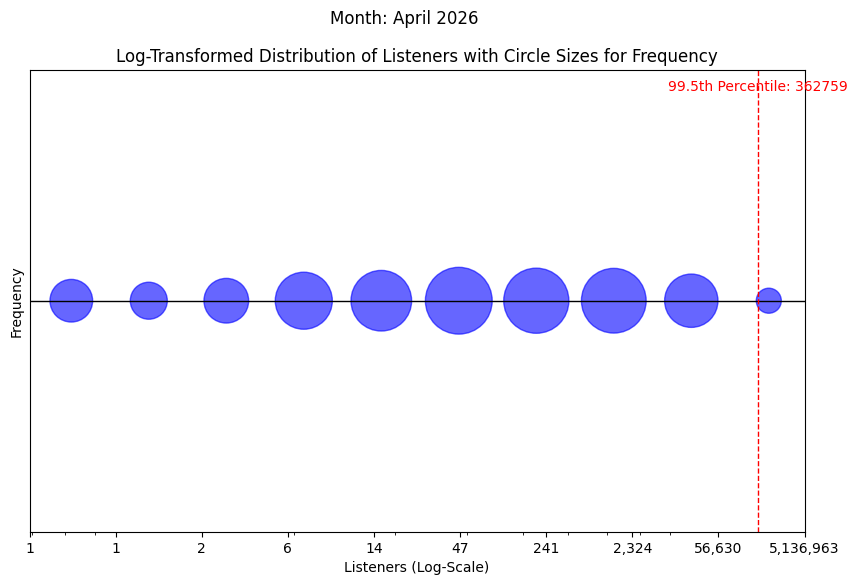

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming listeners_df is already defined
last_month_listeners = listeners_df[listeners_df["month"] == listeners_df["month"].max()]["listeners"]

# Remove non-positive values or replace them with a small positive value
last_month_listeners = last_month_listeners[last_month_listeners > 0]  # Keep only positive values

# Apply log1p transformation
last_month_listeners_log = np.log1p(last_month_listeners)  # log-transform the data for better visualization

# Logarithmic bin edges (using log scale for bin edges)
log_bin_edges = np.logspace(np.log10(last_month_listeners_log.min()), np.log10(last_month_listeners_log.max()), 11)
log_bin_centers = 0.5 * (log_bin_edges[:-1] + log_bin_edges[1:])  # The centers of the bins

# Calculate the frequency (counts) for each bin
hist, _ = np.histogram(last_month_listeners_log, bins=log_bin_edges)

# Plotting
plt.figure(figsize=(10, 6))

# Scatter plot with varying circle sizes based on frequency
# The size of the circles (s) is scaled to make it more visually distinct
plt.scatter(log_bin_centers, np.zeros_like(log_bin_centers), s=hist , color='blue', alpha=0.6)  # Circles on y=0

# Set logarithmic scale for x-axis and label it
plt.xscale('log')
plt.xlabel('Listeners (Log-Scale)')

# Set the x-axis at the middle (y=0)
plt.axhline(0, color='black',linewidth=1)  # Draw x-axis at y=0

# Set labels for the y-axis (turn it off)
plt.ylabel('Frequency')
plt.yticks([])  # Hide the y-ticks

# Add title
plt.title("Log-Transformed Distribution of Listeners with Circle Sizes for Frequency")
plt.suptitle(f"Month: {listeners_df['month'].max().strftime('%B %Y')}")

# Set vertical line for .995 quantile
quantile_95_listeners = int(last_month_listeners.quantile(0.995))
quantile_95 = np.log1p(quantile_95_listeners)
plt.axvline(quantile_95, color='red', linestyle='dashed', linewidth=1)
plt.text(quantile_95, 0.05, f'99.5th Percentile: {quantile_95_listeners}', color='red', ha='center')

# Set x-ticks to represent values in the original scale of listeners (not log-transformed)
tick_values = np.logspace(np.log10(last_month_listeners_log.min()), np.log10(last_month_listeners_log.max()), 10)
plt.xticks(tick_values, [f"{int(np.expm1(tick)):,}" for tick in tick_values])

# Show plot
plt.show()

In [71]:
listeners_thresh = 100_000*(np.ceil(quantile_95_listeners/100_000)) #upper threshold
listeners_thresh = min_300_dollars_listeners = np.float64(270960.345230125)

In [72]:
top_artists = listeners_df[listeners_df["listeners"] >= listeners_thresh][["artist_id","artist_name"]].drop_duplicates().reset_index(drop=True)
top_artists

,artist_id,artist_name
0,39,Luna
1,43,Nervy
2,175,D4C
3,178,HRXSTAL
4,229,SadSvit
...,...,...
153,15414,Klavdia Petrivna
154,15785,kavabanga Depo kolibri
155,15850,LOBODA
156,16101,KOLA


### **Top‑Rated Ukrainian Labels**

For many artists, record labels are a key step in their professional careers. However, in Ukraine, labels don’t function in the same way as the big music industry players elsewhere. **Ukrainian labels don’t guarantee stardom** but serve more as intermediaries between the artist and distributors, helping with the logistical side of music — such as pitching to streaming platforms, offering promotion, and providing community support. These labels often operate like **local communities**, so signing with one is generally not a difficult hurdle for most artists.

However, there are certain labels that have become known for **creating successful artists** and pushing them into larger markets. Below, we define a **top-rated label** as one that has released at least **two artists with 400,000+ monthly listeners**. Let’s look at some of the most prominent ones:

[d3 chart here](home/dataobrii04/PyProjects/nuam_scraper/data/charts/label_rosters/index.html)

* **ENKO Music**: This label is known for its **pop music releases** and has achieved significant success with artists like **Jerry Hail**, **Alyona Alyona**, **KALUSH**, **YAKTAK**, and **Шугар**. ENKO has become synonymous with chart-topping pop talent in Ukraine. It has a particularly strong presence on platforms like Spotify, where many of its artists have reached large audiences.

* **PLAN**: PLAN stands out for having the **highest number of signed artists**, boasting **379 deals in just 2 years**. Despite the impressive number, none of their artists have broken into major mainstream success as of yet.

* **UA Phonk Community**: This is more of a **community-driven label** than a traditional one. It’s focused on the **phonk genre** and has cultivated some high-performing artists. While its model is less commercial than others, it has produced several standout talents that have gathered significant listeners within their niche.

Here’s a list of top-rated labels in Ukraine, each of which has helped shape the current music scene by releasing multiple **high-performing artists**:

* **UA PHONK COMMUNITY**
* **ENKO**
* **BEST MUSIC**
* **YATOMI HOUSE RECORDS**
* **SUNDAY**
* **TAVR Records**
* **CVRSED**
* **pomitni** (a newer label growing rapidly with artists like **Nadya Dorofeyeva** and **Кажанна**)
* **Comp Music**
* **House of Culture and Дім Звукозапису**
* **RADAR RECORDS**
* **OBNYAV**
* **Phonk Workshop**
* **FoxLab**
* **Berserk Records**

For instance, **pomitni** has only been active since **2022** but is already **growing rapidly**, uniting high-potential artists like **Nadya Dorofeyeva** and recent signee **Кажанна**, whose work has been gaining significant attention.

Getting a deal with one of these **15 top-rated labels** is a clear sign of an artist’s potential — **it’s both an opportunity to become great and an endorsement that the artist is already on the path to success**.

In [73]:
top_rated_labels = pd.DataFrame({"label": labels_df[labels_df["artist_id"].isin(top_artists["artist_id"])]["label"].unique()})
top_rated_labels["signed_top_artists"] = top_rated_labels["label"].apply(lambda x: len(labels_df[(labels_df["label"] == x) & labels_df["artist_id"].isin(top_artists["artist_id"])]))

#sort by signed_top_artists
top_rated_labels = top_rated_labels.sort_values("signed_top_artists", ascending=False).reset_index(drop=True)
# Selecting only labels which really producing stars and that is not opportunity for one hit wonder
top_rated_labels = top_rated_labels[top_rated_labels["signed_top_artists"] > 1]

top_rated_labels_df = top_rated_labels.copy()
top_rated_labels = top_rated_labels_df["label"].tolist()


top_rated_labels, len(top_rated_labels)

(['ENKO',
  'UA PHONK COMMUNITY',
  'BEST MUSIC',
  'YATOMI HOUSE RECORDS',
  'Comp Music',
  'МУЛЬТИТРЕК',
  'pomitni',
  'CVRSED',
  'House of Culture and Дім Звукозапису',
  'Mayak Music',
  'SUNDAY',
  'TAVR Records',
  'AURORA RECORDS',
  'Geisha Ninja Samurai',
  'RADAR RECORDS',
  'Phonk Workshop',
  'Berserk Records',
  'FoxLab',
  'OBNYAV',
  'Nova Music',
  'lesfreemusic',
  '100DOLA',
  'Gonivo Records',
  'Catalystic',
  'NPRC MUSIC',
  'Secret Service Digital & Publishing LTD'],
 26)

In [74]:
top_rated_labels_df["signed_top_artists"].max()

np.int64(12)

### 🔍 Verified/Reported Figures for Ukraine (2025)

### 🇺🇦 **Spotify royalty rate estimates for Ukraine (Dec 2025)**

* According to *Dynamoi* data, **Spotify pays roughly:**

  * **~$1.33 per 1,000 paid (premium) streams in Ukraine**
  * **~$0.35 per 1,000 free/ad‑supported streams in Ukraine**
    (i.e., ≈ $0.00133 + $0.00035 respectively per stream) ([Dynamoi][1])

⚠️ *Note:* These figures are derived from a royalty dataset (not an official Spotify report). They are a *market estimate* rather than a published official payout. In many countries lower subscription prices & advertising revenues lead to a comparatively small payout per stream.

[1]: https://dynamoi.com/data/royalties/spotify/ua?utm_source=chatgpt.com "Spotify pays $1.33 RPM in Ukraine (December 2025)"


In [75]:
import pandas as pd

# Clean the extracted text and structure it into a dataframe

# Raw extracted text from OCR
spotify_payouts_2025 = [
    {"date": "Dec 25", "paid": 0.81, "free": 0.81, "paid_12mo_avg": 1.31, "free_12mo_avg": 0.34},
    {"date": "Nov 25", "paid": 1.69, "free": 0.02, "paid_12mo_avg": 1.31, "free_12mo_avg": 0.34},
    {"date": "Sep 25", "paid": 1.69, "free": 0.01, "paid_12mo_avg": 1.24, "free_12mo_avg": 0.41},
    {"date": "Aug 25", "paid": 1.67, "free": 0.00, "paid_12mo_avg": 1.16, "free_12mo_avg": 0.47},
    {"date": "Jul 25", "paid": 1.66, "free": 0.01, "paid_12mo_avg": 1.09, "free_12mo_avg": 0.54},
    {"date": "Jun 25", "paid": 1.65, "free": 0.03, "paid_12mo_avg": 1.02, "free_12mo_avg": 0.61},
    {"date": "May 25", "paid": 0.81, "free": 0.81, "paid_12mo_avg": 0.95, "free_12mo_avg": 0.67},
    {"date": "Apr 25", "paid": 1.67, "free": 0.00, "paid_12mo_avg": 0.95, "free_12mo_avg": 0.67},
    {"date": "Mar 25", "paid": 1.69, "free": 0.01, "paid_12mo_avg": 0.88, "free_12mo_avg": 0.73},
    {"date": "Feb 25", "paid": 0.81, "free": 0.81, "paid_12mo_avg": 0.80, "free_12mo_avg": 0.80},
    {"date": "Jan 25", "paid": 0.81, "free": 0.81, "paid_12mo_avg": 0.80, "free_12mo_avg": 0.80},
]

# Create DataFrame
spotify_payouts_2025 = pd.DataFrame(spotify_payouts_2025)



In [76]:
# Extract relevant data for the new images
new_data = [
    {"date": "Dec 24", "paid": 0.81, "free": 0.81, "paid_12mo_avg": 0.80, "free_12mo_avg": 0.80},
    {"date": "Nov 24", "paid": 0.81, "free": 0.81, "paid_12mo_avg": 0.80, "free_12mo_avg": 0.80},
    {"date": "Oct 24", "paid": 0.81, "free": 0.81, "paid_12mo_avg": 0.80, "free_12mo_avg": 0.80},
    {"date": "Sep 24", "paid": 0.81, "free": 0.81, "paid_12mo_avg": 0.80, "free_12mo_avg": 0.80},
    {"date": "Aug 24", "paid": 0.81, "free": 0.81, "paid_12mo_avg": 0.80, "free_12mo_avg": 0.80},
    {"date": "Jul 24", "paid": 0.81, "free": 0.81, "paid_12mo_avg": 0.88, "free_12mo_avg": 0.80},
    {"date": "Jun 24", "paid": 0.81, "free": 0.81, "paid_12mo_avg": 0.80, "free_12mo_avg": 0.80},
    {"date": "May 24", "paid": 0.78, "free": 0.78, "paid_12mo_avg": 0.80, "free_12mo_avg": 0.80},
    {"date": "Mar 24", "paid": None, "free": 0.81, "paid_12mo_avg": None, "free_12mo_avg": 0.80},
    {"date": "Jan 24", "paid": None, "free": 0.81, "paid_12mo_avg": None, "free_12mo_avg": 0.80},
]

# Convert the new data into DataFrame
spotify_payouts_2024 = pd.DataFrame(new_data)

# Concatenate old and new DataFrames
spotify_payouts_25_24 = pd.concat([spotify_payouts_2024, spotify_payouts_2025], ignore_index=True)

In [77]:
spotify_payouts_25_24

,date,paid,free,paid_12mo_avg,free_12mo_avg
0,Dec 24,0.81,0.81,0.80,0.80
1,Nov 24,0.81,0.81,0.80,0.80
2,Oct 24,0.81,0.81,0.80,0.80
3,Sep 24,0.81,0.81,0.80,0.80
4,Aug 24,0.81,0.81,0.80,0.80
5,Jul 24,0.81,0.81,0.88,0.80
6,Jun 24,0.81,0.81,0.80,0.80
7,May 24,0.78,0.78,0.80,0.80
8,Mar 24,NaN,0.81,NaN,0.80
9,Jan 24,NaN,0.81,NaN,0.80


In [78]:
# Let's first concatenate the old and new DataFrames (spotify_payouts_2024 and spotify_payouts_2025)
# Recreate the 2024 and 2025 data to match previous work and set up the range of months from Jan 2024 to Apr 2026
import numpy as np

# Set up a month range from Jan 2024 to Apr 2026
date_range = pd.date_range(start="2024-01-01", end="2026-04-01", freq="MS")
df_combined = spotify_payouts_25_24.copy()
# Concatenate to ensure the new index follows the month-year pattern
df_combined['date'] = pd.to_datetime(df_combined['date'] , format="%b %y")


# Reindex to new Date Range
df_combined.set_index('date', inplace=True)

df_combined_reindexed = df_combined.reindex(pd.to_datetime(date_range))

# Interpolation to fill missing values
df_combined_interpolated = df_combined_reindexed.interpolate(method='linear')
df_combined_interpolated["paid"] = df_combined_interpolated["paid"].bfill()
df_combined_interpolated

,paid,free,paid_12mo_avg,free_12mo_avg
2024-01-01,0.78,0.810,NaN,0.800
2024-02-01,0.78,0.810,NaN,0.800
2024-03-01,0.78,0.810,NaN,0.800
2024-04-01,0.78,0.795,NaN,0.800
2024-05-01,0.78,0.780,0.800,0.800
2024-06-01,0.81,0.810,0.800,0.800
2024-07-01,0.81,0.810,0.880,0.800
2024-08-01,0.81,0.810,0.800,0.800
2024-09-01,0.81,0.810,0.800,0.800
2024-10-01,0.81,0.810,0.800,0.800


In [79]:
listeners_with_payouts = listeners_df.merge(df_combined_interpolated.reset_index(drop=False).rename(columns={"index": "month"}), on="month", how="left")
listeners_with_payouts


,artist_id,artist_name,listeners,month,paid,free,paid_12mo_avg,free_12mo_avg
0,0,Soundpill,669,2024-04-01,0.78,0.795,NaN,0.80
1,0,Soundpill,543,2024-05-01,0.78,0.780,0.80,0.80
2,0,Soundpill,517,2024-06-01,0.81,0.810,0.80,0.80
3,0,Soundpill,552,2024-07-01,0.81,0.810,0.88,0.80
4,0,Soundpill,474,2024-08-01,0.81,0.810,0.80,0.80
...,...,...,...,...,...,...,...,...
350486,17348,Zombies Eat My Neighbours,0,2025-12-01,0.81,0.810,1.31,0.34
350487,17348,Zombies Eat My Neighbours,0,2026-01-01,0.81,0.810,1.31,0.34
350488,17348,Zombies Eat My Neighbours,0,2026-02-01,0.81,0.810,1.31,0.34
350489,17348,Zombies Eat My Neighbours,0,2026-03-01,0.81,0.810,1.31,0.34


In [80]:
listeners_with_payouts["estimated_min_payout"] = listeners_with_payouts["listeners"]*listeners_with_payouts["paid"]/1000
listeners_with_payouts


,artist_id,artist_name,listeners,month,paid,free,paid_12mo_avg,free_12mo_avg,estimated_min_payout
0,0,Soundpill,669,2024-04-01,0.78,0.795,NaN,0.80,0.52182
1,0,Soundpill,543,2024-05-01,0.78,0.780,0.80,0.80,0.42354
2,0,Soundpill,517,2024-06-01,0.81,0.810,0.80,0.80,0.41877
3,0,Soundpill,552,2024-07-01,0.81,0.810,0.88,0.80,0.44712
4,0,Soundpill,474,2024-08-01,0.81,0.810,0.80,0.80,0.38394
...,...,...,...,...,...,...,...,...,...
350486,17348,Zombies Eat My Neighbours,0,2025-12-01,0.81,0.810,1.31,0.34,0.00000
350487,17348,Zombies Eat My Neighbours,0,2026-01-01,0.81,0.810,1.31,0.34,0.00000
350488,17348,Zombies Eat My Neighbours,0,2026-02-01,0.81,0.810,1.31,0.34,0.00000
350489,17348,Zombies Eat My Neighbours,0,2026-03-01,0.81,0.810,1.31,0.34,0.00000


In [81]:
print("Total estimated payout for Ukraine in 2024-2026:")
print(f"{listeners_with_payouts["estimated_min_payout"].sum()/100000:.1f}M $")

Total estimated payout for Ukraine in 2024-2026:
33.8M $


<Axes: title={'center': 'Estimated Payout for Ukraine in 2024-2026'}, xlabel='month'>

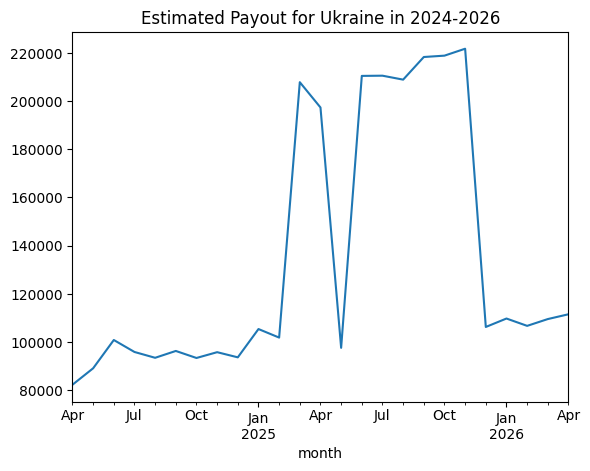

In [82]:
listeners_with_payouts.groupby("month")["estimated_min_payout"].sum().plot(kind="line", title="Estimated Payout for Ukraine in 2024-2026")

In [83]:
df_plot = listeners_with_payouts[listeners_with_payouts["month"] >= "2025-01-01"].groupby(
    ["month", "artist_name"], as_index=False
)["estimated_min_payout"].sum()
top50 = (
    df_plot.groupby("artist_name")["estimated_min_payout"].sum()
    .sort_values(ascending=False)
    .head(50)
    .index
)

df_top50 = df_plot[df_plot["artist_name"].isin(top50)]
# Pivot to wide format if needed
df_wide = df_top50.pivot(
    index="month",
    columns="artist_name",
    values="estimated_min_payout"
)

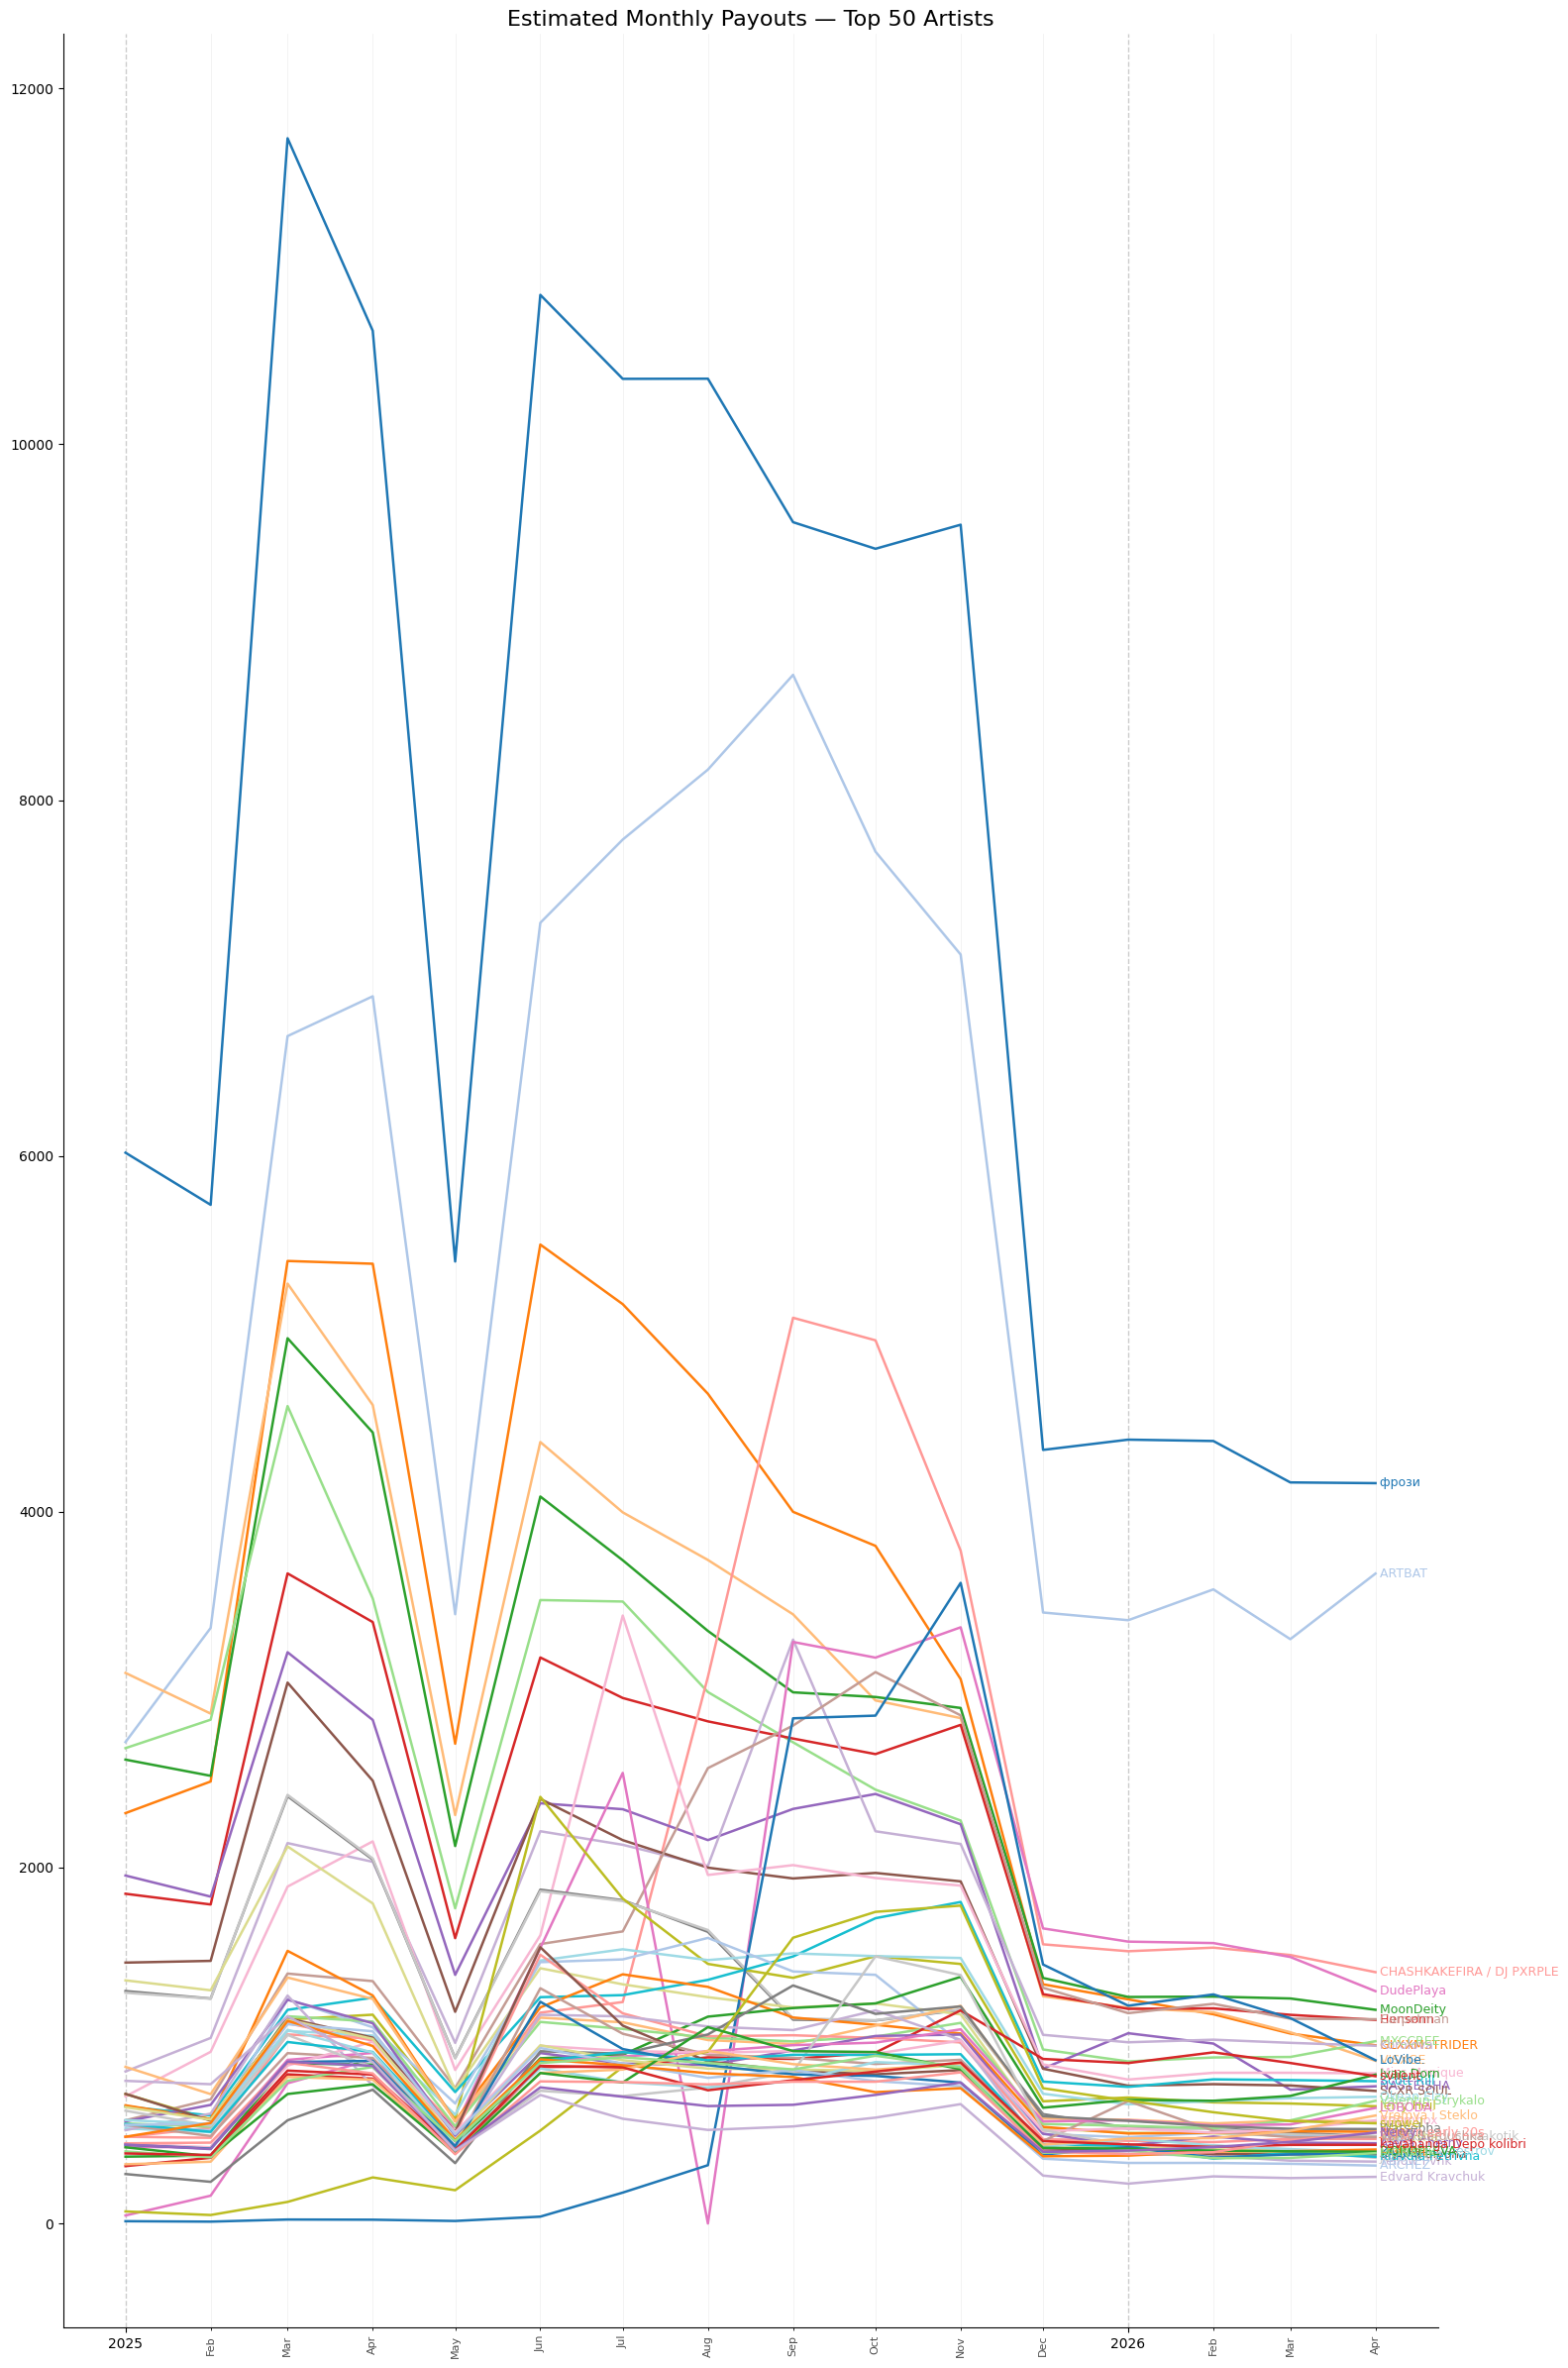

In [84]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(16, 24))
ax = plt.gca()

# Plot lines & label artists
for i, artist in enumerate(top50):
    if artist in df_wide.columns:
        y = df_wide[artist]
        x = df_wide.index
        color = plt.get_cmap("tab20")(i % 20)

        ax.plot(x, y, color=color, linewidth=1.8)

        last_idx = y.last_valid_index()
        if last_idx is not None:
            ax.text(
                last_idx,
                y.loc[last_idx],
                f" {artist}",
                fontsize=9,
                color=color,
                va="center"
            )

# --- X‑AXIS: BOTH YEARS & MONTHS ---

# Major ticks at start of each year
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Minor ticks at start of each month
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

# Style minor tick labels for readability
plt.setp(ax.xaxis.get_minorticklabels(), rotation=90, fontsize=8, alpha=0.7)

# Light grid lines
ax.grid(axis="x", which="minor", color="#eeeeee", linestyle='-', linewidth=0.5)
ax.grid(axis="x", which="major", color="#cccccc", linestyle='--', linewidth=1)

# Clean up spines for editorial look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Estimated Monthly Payouts — Top 50 Artists", fontsize=16)
plt.tight_layout()
plt.show()

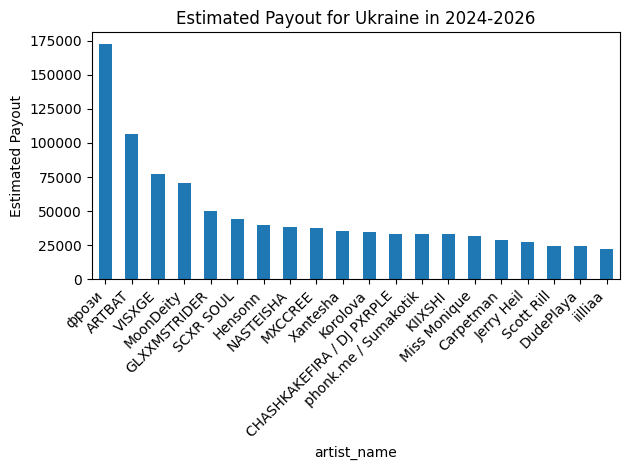

In [85]:
listeners_with_payouts.groupby("artist_name")["estimated_min_payout"].sum().sort_values(ascending=False).head(20).plot(kind="bar", title="Estimated Payout for Ukraine in 2024-2026")
plt.ylabel("Estimated Payout")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1318234/2333302909.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{int(np.expm1(tick)):,}" for tick in ticks])


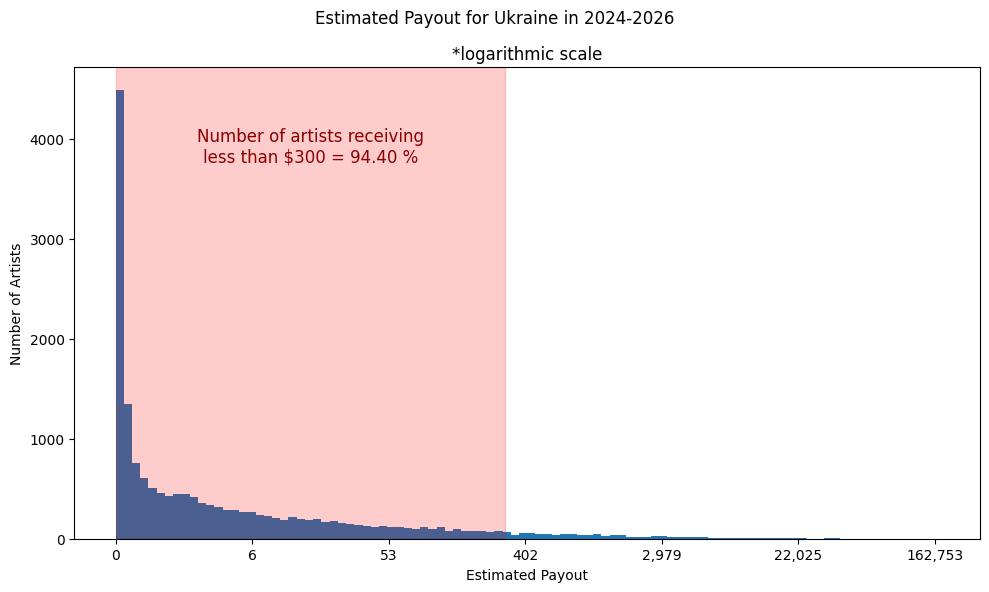

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# Compute log payouts & count
log_vals = np.log1p(listeners_with_payouts.groupby("artist_name")["estimated_min_payout"].sum())
threshold_log = np.log1p(300)

count_under_300 = (listeners_with_payouts.groupby("artist_name")["estimated_min_payout"].sum() < 300).sum()/listeners_with_payouts["artist_name"].nunique()

# Draw histogram
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(log_vals, bins=100)

plt.suptitle("Estimated Payout for Ukraine in 2024‑2026")
plt.title("*logarithmic scale")
plt.xlabel("Estimated Payout")
plt.ylabel("Number of Artists")

# Draw shaded rectangle BELOW the threshold (semi‑transparent)
ax.axvspan(0, threshold_log, color='red', alpha=0.2)

# Annotate with custom text
ax.text(
    threshold_log * 0.5,  # half‑way into the shaded zone
    ax.get_ylim()[1] * 0.8,  # high up in the y axis
    f"Number of artists receiving\nless than $300 = {100*count_under_300:.2f} %",
    color='darkred',
    fontsize=12,
    ha="center"
)

# Reformat x ticks to show original scale (expm1 transform)
ticks = ax.get_xticks()
ax.set_xticklabels([f"{int(np.expm1(tick)):,}" for tick in ticks])

plt.tight_layout()
plt.show()

In [87]:
# Validation

listeners_with_payouts[listeners_with_payouts["artist_name"] == "Октавіан Серпень"]["estimated_min_payout"].sum()

np.float64(54.7198)

In [88]:
listeners_with_payouts[listeners_with_payouts["estimated_min_payout"]>300]

,artist_id,artist_name,listeners,month,paid,free,paid_12mo_avg,free_12mo_avg,estimated_min_payout
867,39,Luna,195230,2025-03-01,1.69,0.010,0.880,0.730,329.93870
868,39,Luna,183126,2025-04-01,1.67,0.000,0.950,0.670,305.82042
874,39,Luna,194320,2025-10-01,1.69,0.015,1.275,0.375,328.40080
875,39,Luna,268740,2025-11-01,1.69,0.020,1.310,0.340,454.17060
956,43,Nervy,440800,2024-04-01,0.78,0.795,NaN,0.800,343.82400
...,...,...,...,...,...,...,...,...,...
328777,16101,KOLA,344256,2025-08-01,1.67,0.000,1.160,0.470,574.90752
328778,16101,KOLA,320082,2025-09-01,1.69,0.010,1.240,0.410,540.93858
328779,16101,KOLA,312581,2025-10-01,1.69,0.015,1.275,0.375,528.26189
328780,16101,KOLA,319706,2025-11-01,1.69,0.020,1.310,0.340,540.30314


In [89]:
#min_300_dollars_listeners = 1000*300/(listeners_with_payouts["paid"].mean())

min_300_dollars_listeners = np.float64(270960.345230125)

In [90]:
artists_with_payouts = listeners_with_payouts.groupby("artist_name")["estimated_min_payout"].sum()

In [91]:
artists_with_payouts_id = listeners_with_payouts.groupby("artist_id")["estimated_min_payout"].sum()
plan_artist_ids = labels_df.loc[labels_df["label"] == "PLAN", "artist_id"].unique()
plan_payouts = listeners_with_payouts.set_index("artist_id").loc[listeners_with_payouts.set_index("artist_id").index.isin(plan_artist_ids)]
plan_payouts

,artist_name,listeners,month,paid,free,paid_12mo_avg,free_12mo_avg,estimated_min_payout
artist_id,,,,,,,,
1,Monkey Shock Band,3600,2024-04-01,0.78,0.795,NaN,0.80,2.80800
1,Monkey Shock Band,1900,2024-05-01,0.78,0.780,0.80,0.80,1.48200
1,Monkey Shock Band,82,2024-06-01,0.81,0.810,0.80,0.80,0.06642
1,Monkey Shock Band,78,2024-07-01,0.81,0.810,0.88,0.80,0.06318
1,Monkey Shock Band,55,2024-08-01,0.81,0.810,0.80,0.80,0.04455
...,...,...,...,...,...,...,...,...
16575,Cherry,0,2025-12-01,0.81,0.810,1.31,0.34,0.00000
16575,Cherry,0,2026-01-01,0.81,0.810,1.31,0.34,0.00000
16575,Cherry,0,2026-02-01,0.81,0.810,1.31,0.34,0.00000


In [92]:
plan_payouts.groupby("artist_id")["estimated_min_payout"].mean().max()

np.float64(183.03718959999998)

<Axes: xlabel='month'>

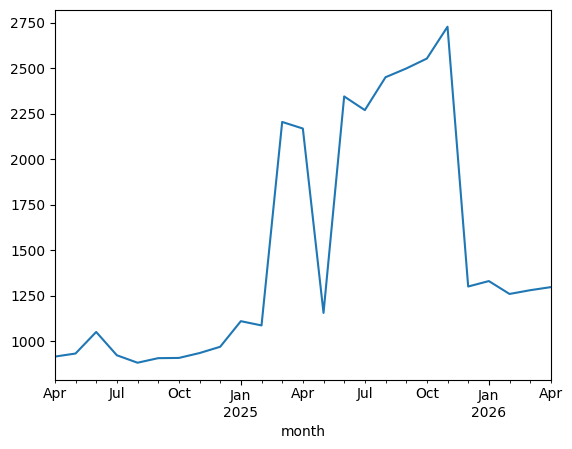

In [93]:
plan_payouts.groupby("month")["estimated_min_payout"].sum().plot()

In [97]:
plan_payouts[plan_payouts["estimated_min_payout"]<100].groupby("month")["estimated_min_payout"].sum().mean()

np.float64(1155.0748924)

### **How Mature Is Ukraine’s Music Market?**

To get a sense of how mature the Ukrainian music market is, I’m using a framework from  [-*The Unlikely Odds of Making it Big on TikTok*](https://pudding.cool/2022/07/tiktok-story/)
 by Pudding.cool. They came up with a list of milestones for measuring an artist's growth, like:

1. Played a live show
2. Signed a record deal
3. Charted with new songs
4. Got on Spotify playlists
5. 100K+ Instagram followers
6. 100K+ YouTube subscribers
7. 1M+ Spotify monthly listeners
8. Played a music festival

While these are great markers, we don’t have data for some of them just yet (like live shows or social media followers). So, I adapted things a bit to focus on the data that we do have for Ukraine. Here’s the adjusted list of milestones for gauging artist maturity in our market:

#### **Revised Milestones for Ukrainian Artists**

* ✅ **Signed with a top-rated label** — shows industry recognition
* ✅ **Has a Spotify profile** — means they’re globally distributed
* ✅ **Has an Instagram account** — a basic social presence
* ✅ **Debuted within the last 3 years (2024, 2025, 2026)** — highlights artists who are currently on the rise
* 🔥 **Spotify monthly listeners ≥ 1M** — indicates a strong, established audience (just like in the original framework)

These milestones give us a good idea of who’s making waves in the Ukrainian music scene.

#### **Milestones Distribution**

 [d3 chart here](home/dataobrii04/PyProjects/nuam_scraper/data/charts/milestones/index.html)

The chart above breaks down where different Ukrainian artists stand based on these milestones. A couple of things are worth noting:

* **Golden-framed artists** in the chart are the ones who still use **Russian** in their songs.

  * Since 2022, most Ukrainian artists have shifted to using Ukrainian or mixed languages in their work, moving away from Russian-language songs.

* You can see how artists are spread out across different listener ranges, from around 70,000 to 1.5 million monthly listeners.

  * For example, **Ivan Dorn** and **Okean Elzy** both hit the 1M listeners mark, showing that even with different styles and languages, both have managed to build strong followings.

What this chart shows is that, even though Ukraine’s market might not have all the classic markers of maturity (like big festivals or charting history), we’re still seeing artists break through, get solid industry support, and build significant global audiences.

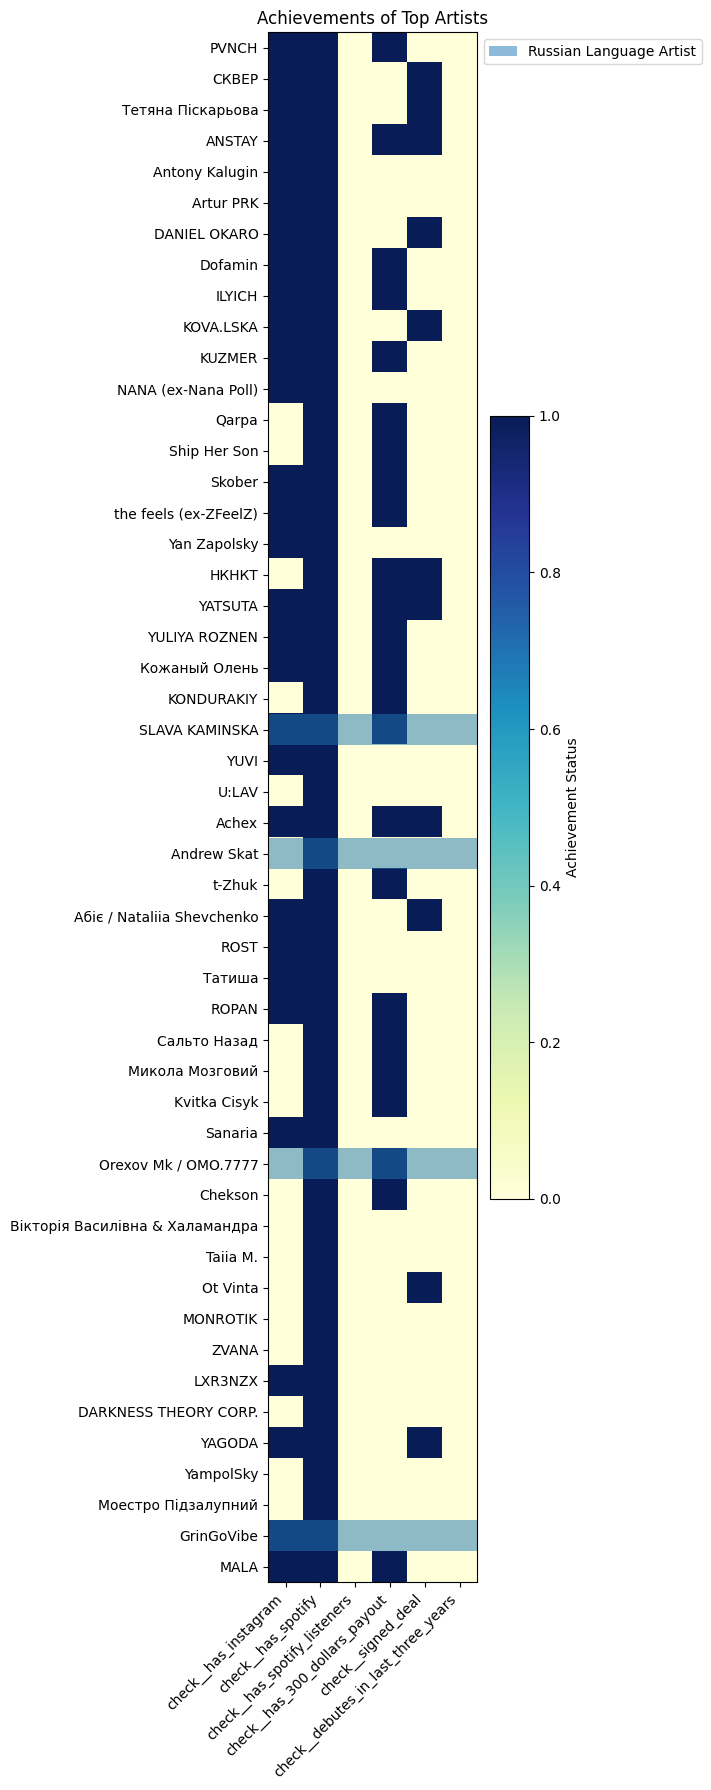

In [ ]:
spotify_listeners_criteria = 1_000_000 
shift = 1000
n_artists = 50

# group by artist_id, take the max listeners per artist
artist_max = listeners_df.groupby("artist_id")["listeners"].max()

# sort descending and pick the top n_artists
selected_artists = artist_max.sort_values(ascending=False)[shift:shift+n_artists].index

achievements_by_artist = artists_df.copy()

# Sorting
achievements_by_artist["listeners"] = achievements_by_artist["artist_id"].map(listeners_df.groupby("artist_id")["listeners"].max())

achievements_by_artist["check__has_instagram"] = achievements_by_artist["instagram"].notna()
achievements_by_artist["check__has_spotify"] = achievements_by_artist["spotify"].notna()
achievements_by_artist["check__has_spotify_listeners"] = (achievements_by_artist["listeners"] >= spotify_listeners_criteria)

achievements_by_artist["check__has_300_dollars_payout"] = achievements_by_artist["artist_id"].map(listeners_with_payouts.groupby("artist_id")["estimated_min_payout"].sum() >= 300).fillna(False).astype(bool)


_signed_ids = labels_df.loc[labels_df["label"].isin(top_rated_labels), "artist_id"].unique()
achievements_by_artist["check__signed_deal"] = achievements_by_artist["artist_id"].isin(_signed_ids)
achievements_by_artist["check__debutes_in_last_three_years"] = achievements_by_artist["artist_id"].isin(debut_df[debut_df["is_debuted"] & debut_df["year"] >= (listeners_df["month"].max().year - 3)]["artist_id"])

# Plot for top artists their achievements
top_achievers = achievements_by_artist[achievements_by_artist["artist_id"].isin(selected_artists)]
achievement_cols = [col for col in achievements_by_artist.columns if col.startswith("check__")]

achievements_by_artist.sort_values("listeners", ascending=False, inplace=True)

#Draw heatmap of achievements for top artists
plt.figure(figsize=(6, 18))
plt.imshow(top_achievers[achievement_cols].values, aspect='auto', cmap='YlGnBu')
plt.colorbar(label='Achievement Status')
plt.yticks(ticks=np.arange(len(top_achievers)), labels=top_achievers["artist_name"])
plt.xticks(ticks=np.arange(len(achievement_cols)), labels=achievement_cols, rotation=45, ha='right')
plt.title("Achievements of Top Artists")
plt.tight_layout()

# Mark artists with ru_lang_flag in the heatmap
for i, (index, row) in enumerate(top_achievers.iterrows()):
    if row["ru_lang_flag"]:
        plt.gca().add_patch(plt.Rectangle((-0.5, i-0.5), len(achievement_cols), 1, fill="red", edgecolor='None', linewidth=2, alpha=0.5))

# Add legend for the red border indicating Russian language artists
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(edgecolor='None', fill="red", alpha=0.5, label='Russian Language Artist', linewidth=2)

# Set custom location to not overlap with the heatmap
plt.legend(handles=[red_patch], loc='upper left', bbox_to_anchor=(1, 1))

plt.show()


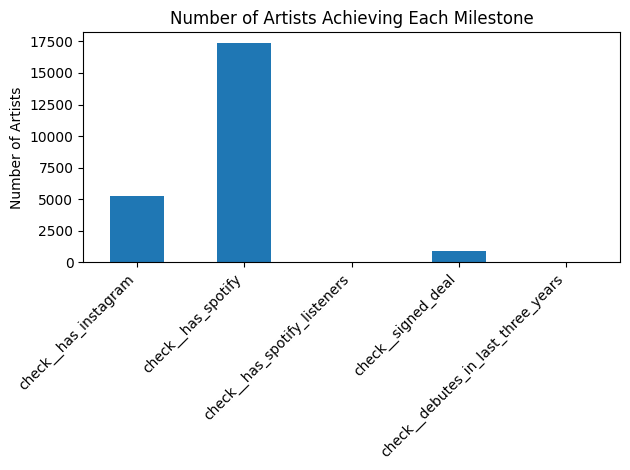

In [ ]:
achievement_cols = [col for col in achievements_by_artist.columns if col.startswith("check__")]
achievement_counts = achievements_by_artist[achievement_cols].sum()
achievement_counts.plot(kind="bar", title="Number of Artists Achieving Each Milestone")
plt.ylabel("Number of Artists")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

check__has_instagram: 5287 artists achieved this milestone
Listeners for artists who achieved check__has_instagram: min=0.0, max=9459991.0, median=1025.0


/tmp/ipykernel_526489/472518985.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f"{int(np.expm1(tick)):,}" for tick in ticks])


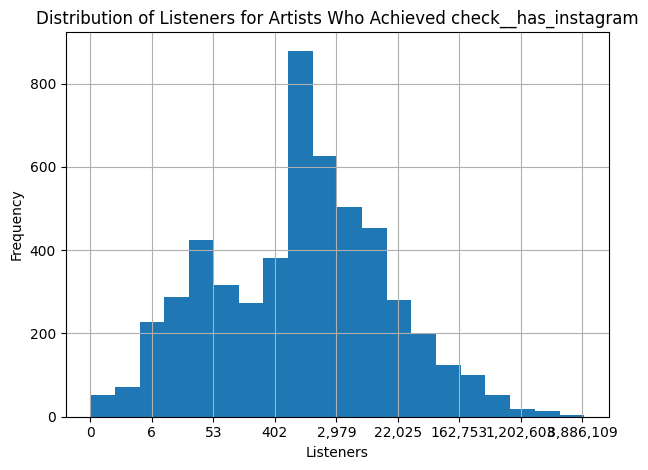

check__has_spotify: 17349 artists achieved this milestone
Listeners for artists who achieved check__has_spotify: min=0.0, max=9459991.0, median=231.0


/tmp/ipykernel_526489/472518985.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f"{int(np.expm1(tick)):,}" for tick in ticks])


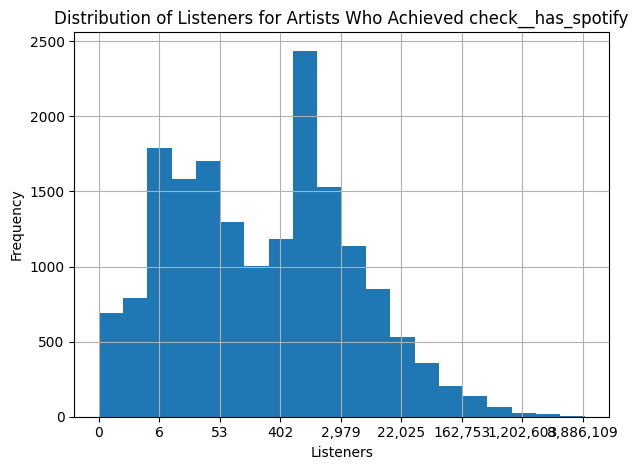

check__has_spotify_listeners: 36 artists achieved this milestone
Listeners for artists who achieved check__has_spotify_listeners: min=1032640.0, max=9459991.0, median=2052929.5


/tmp/ipykernel_526489/472518985.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f"{int(np.expm1(tick)):,}" for tick in ticks])


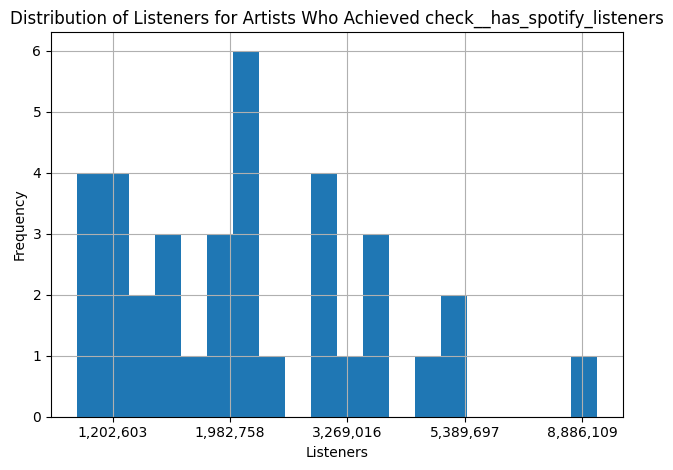

check__signed_deal: 886 artists achieved this milestone
Listeners for artists who achieved check__signed_deal: min=1.0, max=4739102.0, median=6374.0


/tmp/ipykernel_526489/472518985.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f"{int(np.expm1(tick)):,}" for tick in ticks])


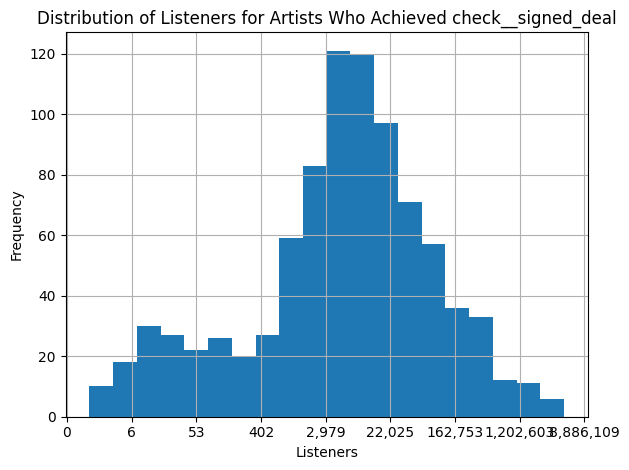

check__debutes_in_last_three_years: 0 artists achieved this milestone
Listeners for artists who achieved check__debutes_in_last_three_years: min=nan, max=nan, median=nan


/home/dataobrii04/PyProjects/nuam_scraper/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1592: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/tmp/ipykernel_526489/472518985.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f"{int(np.expm1(tick)):,}" for tick in ticks])


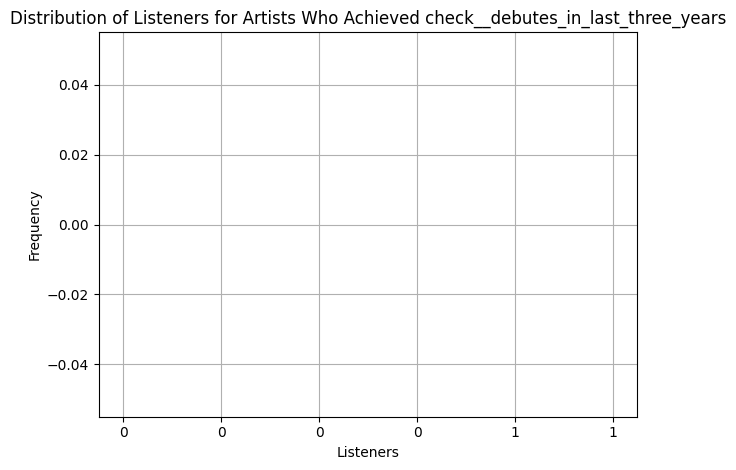

In [ ]:
from collections import defaultdict

# How much minimal artist need to achieve any from check__ columns 
achievement_cols = [col for col in achievements_by_artist.columns if col.startswith("check__")]
achievements_min = defaultdict(list)
for col in achievement_cols:
    print(f"{col}: {achievements_by_artist[col].sum()} artists achieved this milestone")
    # for each achivments select artists that achieved it and select their listeners minimum, maximum and median
    achieved_artists = achievements_by_artist[achievements_by_artist[col]]
    print(f"Listeners for artists who achieved {col}: min={achieved_artists['listeners'].min()}, max={achieved_artists['listeners'].max()}, median={achieved_artists['listeners'].median()}")
    
    if col != "check__has_spotify_listeners":
        achievements_min[col].append(np.nanquantile(achieved_artists["listeners"], 0.01))
    
    # Plot distribution of listeners for artists who achieved this milestone
    _log = np.log1p(achieved_artists["listeners"])
    _log.hist(bins=20)
    plt.title(f"Distribution of Listeners for Artists Who Achieved {col}")
    plt.xlabel("Listeners")
    plt.ylabel("Frequency")

    # Set ticks to original scale
    ticks = plt.gca().get_xticks()
    plt.gca().set_xticklabels([f"{int(np.expm1(tick)):,}" for tick in ticks])  
    plt.tight_layout()
    plt.show()

### **Genres**

I also looked at music from the listeners’ side — in particular, **which genres attract the most listeners** and which ones are actually *under‑represented* compared to their audience size.

What’s interesting is that **not all genres are proportional** — some styles have way more ears listening to them than artists making that music. So I pulled out the genres that **have a lot of listeners but fewer artists creating in them**, which might signal opportunities for the scene.

[d3 chart here](nuam_scraper/data/charts/genres_popularity/index.html)

A couple of takeaways:

* **Ukrainian Phonk** naturally shows up with a strong listener base. Phonk — a genre blending electronic beats with hip‑hop influences — has grown a pretty passionate following both here and beyond, and Ukrainian phonk playlists and tracks have circulations online and on streaming platforms. 

* On the flipside, **experimental genres** like **noise, glitch, and dark** pull in listeners even though there aren’t many artists working in those spaces. These styles are niche and avant‑garde, which makes their listener support stand out.

* Classic styles like **emo, opera, and blues** also show up as having listeners but relatively fewer active artists. That doesn’t mean these genres don’t matter — they clearly have people tuning in — just that not as many creators are releasing in them right now.

In simple terms: **some genres have big audiences but not many artists representing them**. That gap tells us something about both listener curiosity and where creative growth might happen next in the Ukrainian music market.

Here’s an extended, **natural and friendly** addition to the phonk description with a bit of history about Ukrainian phonk:

---

Ukrainian phonk has grown out of the global phonk movement and taken on its own life here at home. Phonk as a genre started as a web‑focused blend of hip‑hop and trap rooted in ‘90s Memphis rap, and later evolved into harder, bass‑heavy styles that exploded online and especially through communities on SoundCloud and TikTok. 

In Ukraine, a local **phonk scene** emerged in the late 2010s and early 2020s, driven by underground artists and collectives like **Ukrainian Phonk Community**, which brought producers and beat‑makers together around this dark, atmospheric sound. 

Today Ukrainian phonk blends classic phonk vibes with local energy — drifting basslines, eerie melodies and that late‑night underground feeling — and has a solid listener base both here and abroad, even though most of the artists are still independent and community‑driven. 

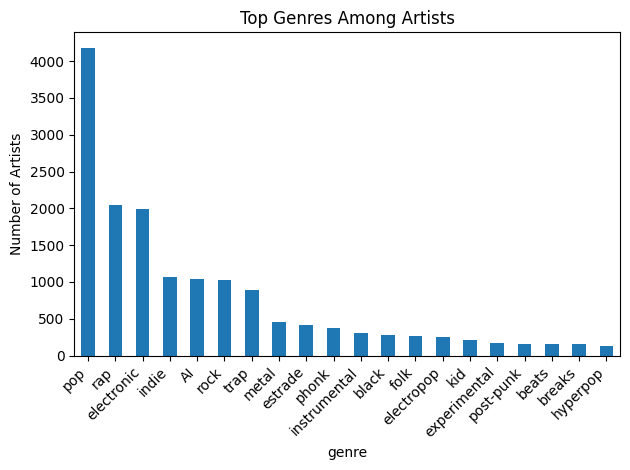

In [ ]:
core_genres = genres_df.groupby("artist_id")["genre"].first()
core_genres.value_counts().head(20).plot(kind="bar", title="Top Genres Among Artists")
plt.ylabel("Number of Artists")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()  

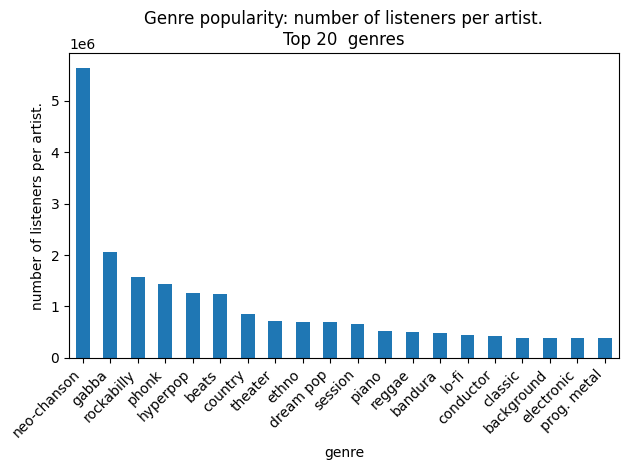

In [ ]:
genres_stats = genres_df["genre"].value_counts()
#convert to dataframe
genres_stats = genres_stats.to_frame().reset_index(drop=False).rename(columns={"index": "genre", "count": "artist_count"})

# Calculate how much listeners in genre
#Outer merge for genres_df and listeners_df by artist_id
genres_with_listeners = genres_df.merge(listeners_df, on="artist_id", how="outer")[["artist_id", "genre", "listeners", "month"]]
# print(_genres_stats)
# # Group by genre and sum listeners
_mapping = genres_with_listeners.groupby("genre")["listeners"].sum()

 # Merge genres_stats with _genres_stats to add listeners_count to each genre
genres_stats["listeners_count"] = genres_stats["genre"].map(lambda x:_mapping.loc[x] if x in _mapping.index else 0).values

genres_stats["listeners_per_artist"] = genres_stats["listeners_count"]/genres_stats["artist_count"]
genres_stats = genres_stats[genres_stats["listeners_count"]>0]
genres_stats.sort_values("listeners_per_artist", ascending=False, inplace=True)

genres_stats.set_index("genre")["listeners_per_artist"][:20].plot(kind="bar", title="Listeners per Artist by Genre")
plt.title("Genre popularity: number of listeners per artist.\nTop 20  genres")
plt.ylabel("number of listeners per artist.")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# (100*(genres_stats["listeners_per_artist"]/100).astype(int)).hist(bins=20)

# genres_stats["listeners_per_artist"].min()

genres_stats[genres_stats["listeners_per_artist"]<np.nanquantile(genres_stats["listeners_per_artist"], 0.25)]

,genre,artist_count,listeners_count,listeners_per_artist
84,drummer,7,151518.0,21645.428571
5,trap,1142,24352003.0,21323.995622
48,opera,36,695525.0,19320.138889
17,kid,237,4468934.0,18856.261603
35,emo,66,1209393.0,18324.136364
93,jazz rock,3,54190.0,18063.333333
58,poems,22,394332.0,17924.181818
74,surf,13,200771.0,15443.923077
52,heavy,25,373183.0,14927.320000
70,blues,15,210901.0,14060.066667


In [ ]:
genres_with_listeners.groupby(["genre", "month"])["listeners"].sum().reset_index(drop=False).sort_values(["listeners"], ascending=False).head(20)


,genre,month,listeners
1770,pop,2026-04-01,46777929.0
1767,pop,2026-01-01,45648663.0
1769,pop,2026-03-01,45229748.0
1768,pop,2026-02-01,43396599.0
1766,pop,2025-12-01,43053708.0
1765,pop,2025-11-01,42233328.0
1748,pop,2024-06-01,41659028.0
1764,pop,2025-10-01,41048512.0
1762,pop,2025-08-01,40783131.0
763,electronic,2025-09-01,40743194.0


### **Strange Deals**

Have you noticed the small details on the chart about signed deals? We definitely did.

Some of the deals you see are what we call **"zero-shot" deals** — where an artist signs with a label and releases music with no real prior background or track record. It's like diving into the deep end without much of a swimming history!

You can explore more on this here: [d3 chart](home/dataobrii04/PyProjects/nuam_scraper/data/charts/signed_deals/index.html).


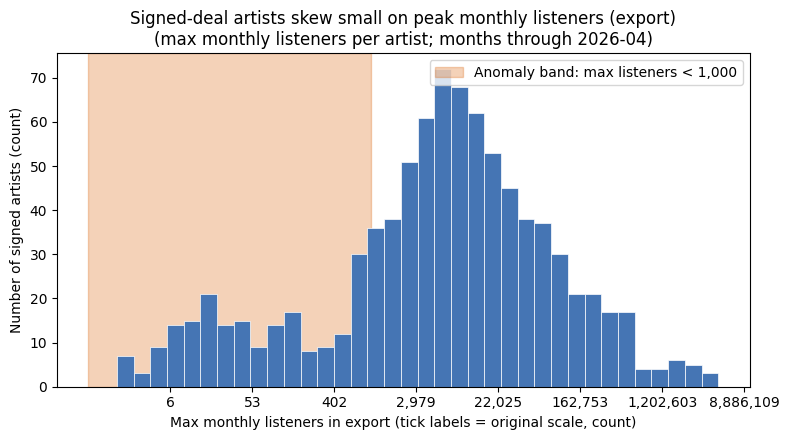

In [ ]:
STRANGE_MAX = 1_000
LABEL_MIN_LISTENERS = 10_000

achieved_artists = achievements_by_artist[achievements_by_artist["check__signed_deal"]].copy()

# 1) Peak listeners among signed-deal artists; highlight <1,000 (anomaly band on log1p scale)
log_listen = np.log1p(achieved_artists["listeners"].to_numpy(dtype=float))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(log_listen, bins=36, color="#4575b4", edgecolor="white", linewidth=0.5)
ax.axvspan(0.0, np.log1p(STRANGE_MAX), alpha=0.28, color="#d95f02", zorder=0, label=f"Anomaly band: max listeners < {STRANGE_MAX:,}")
ax.set_xlabel("Max monthly listeners in export (tick labels = original scale, count)")
ax.set_ylabel("Number of signed artists (count)")
_month_hi = listeners_df["month"].max()
ax.set_title(
    "Signed-deal artists skew small on peak monthly listeners (export)\n"
    f"(max monthly listeners per artist; months through {_month_hi:%Y-%m})"
)
ticks = np.array(ax.get_xticks())
ticks = ticks[(ticks >= log_listen.min()) & (ticks <= log_listen.max() + 1)]
ax.set_xticks(ticks)
ax.set_xticklabels([f"{int(np.expm1(t)):,}" for t in ticks])
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()